# 02. Framing, lexique et émotions

**Objectif** : Analyser l'évolution des cadres discursifs (framing), du stance, de l'adoption du cessez-le-feu par bloc, de la polarisation lexicale et des registres émotionnels.

## 0. Setup et configuration

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, COLORS, BLOCS_ORDER

warnings.filterwarnings("ignore")

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = FIGURES_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVENTS = [
    ("2023-10-07", "7 oct."), ("2024-01-26", "CIJ"), ("2024-05-28", "Rafah"),
    ("2024-10-16", "Sinwar"), ("2024-11-21", "CPI"), ("2025-01-19", "CF"), ("2025-03-15", "Rupture")
]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def add_events(ax, ymax_frac=0.97, fontsize=6.5):
    ylim = ax.get_ylim()
    for date_str, label in EVENTS:
        dt = pd.Timestamp(date_str)
        ax.axvline(dt, color="gray", lw=0.8, ls="--", alpha=0.45, zorder=0)
        ax.text(dt, ylim[1] * ymax_frac, label, fontsize=fontsize, ha="center", va="top", color="#777777")

print(f"Données : {RESULTS_DIR}")

Données : d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\gaza_discourse_analysis\data\resultats_NB0-NB7


## 2.1 Évolution du stance mensuel par bloc

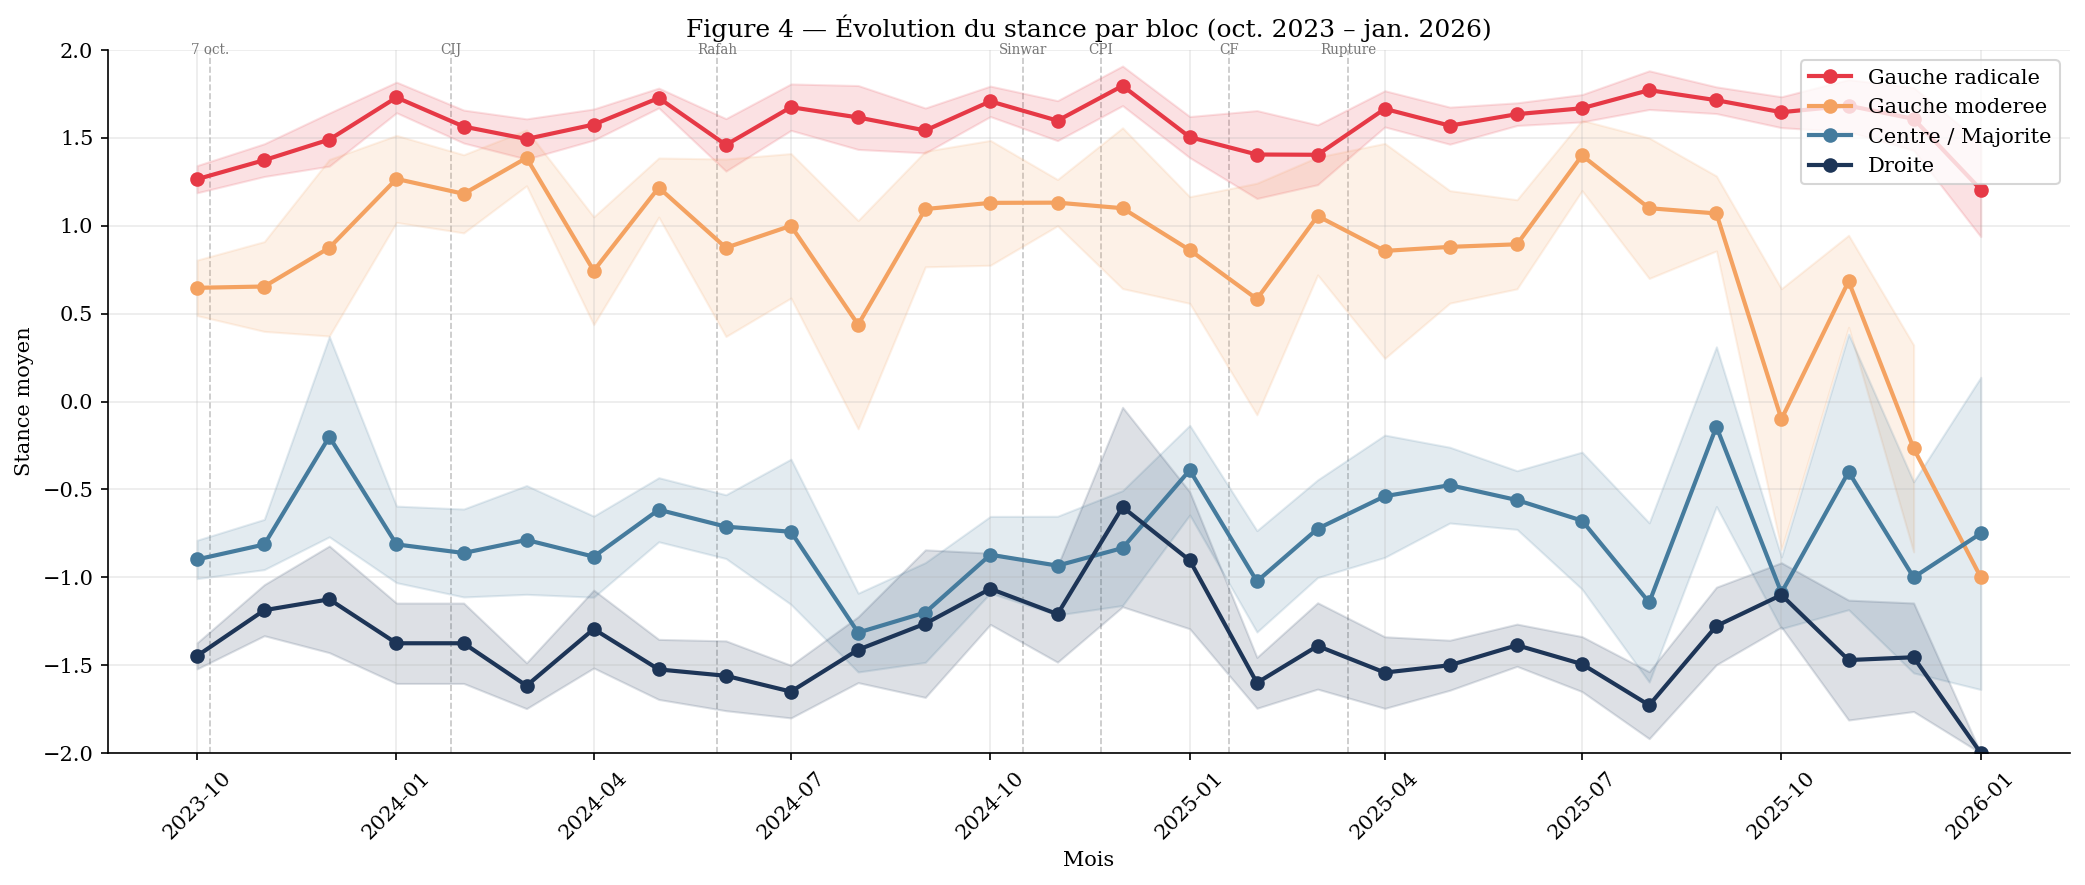

Figure 4 sauvegardée.


In [2]:
stance_mensuel = pd.read_csv(RESULTS_DIR / "stance_mensuel.csv")
stance_mensuel["month"] = pd.to_datetime(stance_mensuel["month_ts"])

# Figure 10. Ribbon plot du stance (IC 95% bootstrappé)
fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOCS_ORDER:
    df = stance_mensuel[stance_mensuel["bloc"] == bloc].sort_values("month")
    if len(df) > 0:
        c = COLORS[bloc]
        ax.fill_between(df["month"], df["ci95_lo"], df["ci95_hi"], alpha=0.15, color=c)
        ax.plot(df["month"], df["stance_mean"], "o-", label=bloc, color=c, lw=2)
add_events(ax)
ax.set_xlabel("Mois")
ax.set_ylabel("Stance moyen")
ax.set_title("Figure 4. Évolution du stance par bloc (oct. 2023 – jan. 2026)")
ax.legend(loc="upper right")
ax.set_ylim(-2, 2)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_stance_evolution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 4 sauvegardée.")

**Interprétation** : Le stance reste polarisé tout au long de la période. La Gauche radicale et la Droite maintiennent des positions aux extrémités du spectre. Le Centre/Majorité et la Gauche modérée occupent des positions intermédiaires. Les lignes verticales marquent les événements pivot (CIJ, Rafah, CPI, etc.).

## 2.2 Diffusion du cessez-le-feu

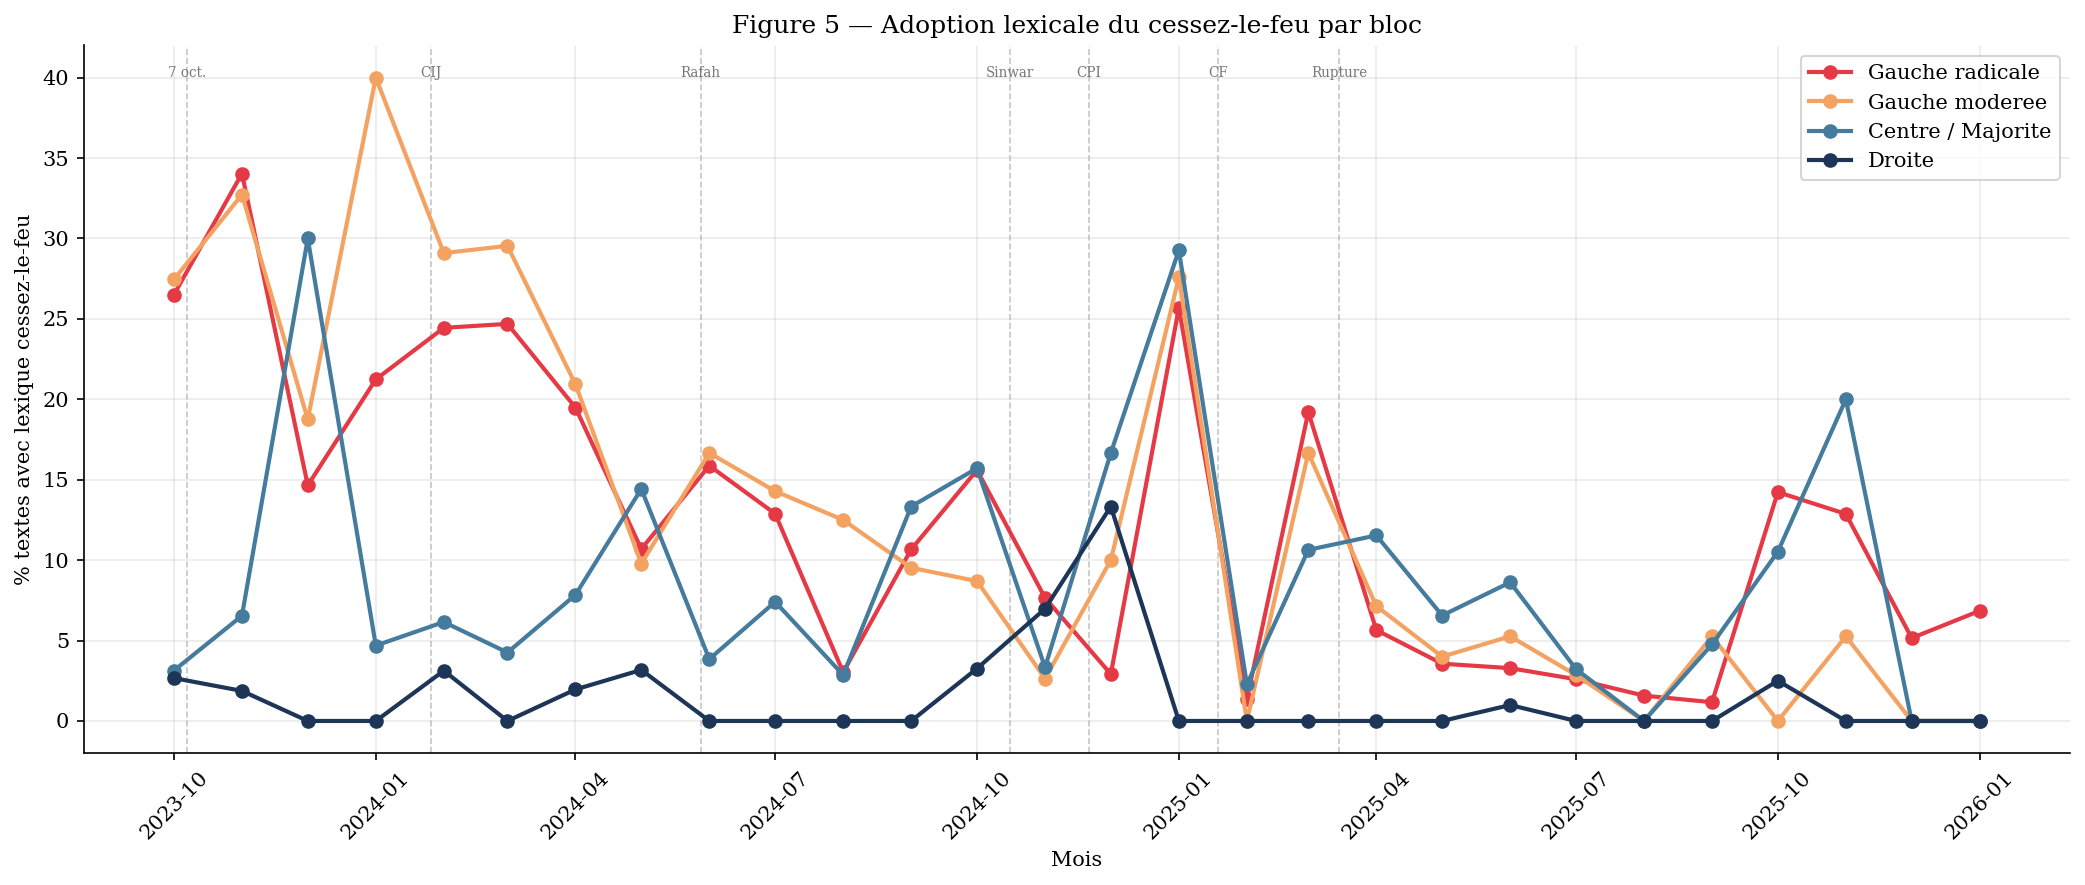

Figure 5 sauvegardée.


In [3]:
ceasefire_lex = pd.read_csv(RESULTS_DIR / "ceasefire_lexical_v3.csv")
ceasefire_lex["month"] = pd.to_datetime(ceasefire_lex["month"] + "-01")

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOCS_ORDER:
    df = ceasefire_lex[ceasefire_lex["bloc"] == bloc]
    if len(df) > 0:
        ax.plot(df["month"], df["pct_ceasefire"], "o-", label=bloc, color=COLORS[bloc], lw=2)
add_events(ax)
ax.set_xlabel("Mois")
ax.set_ylabel("% textes avec lexique cessez-le-feu")
ax.set_title("Figure 5. Adoption lexicale du cessez-le-feu par bloc")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_ceasefire_diffusion.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 5 sauvegardée.")

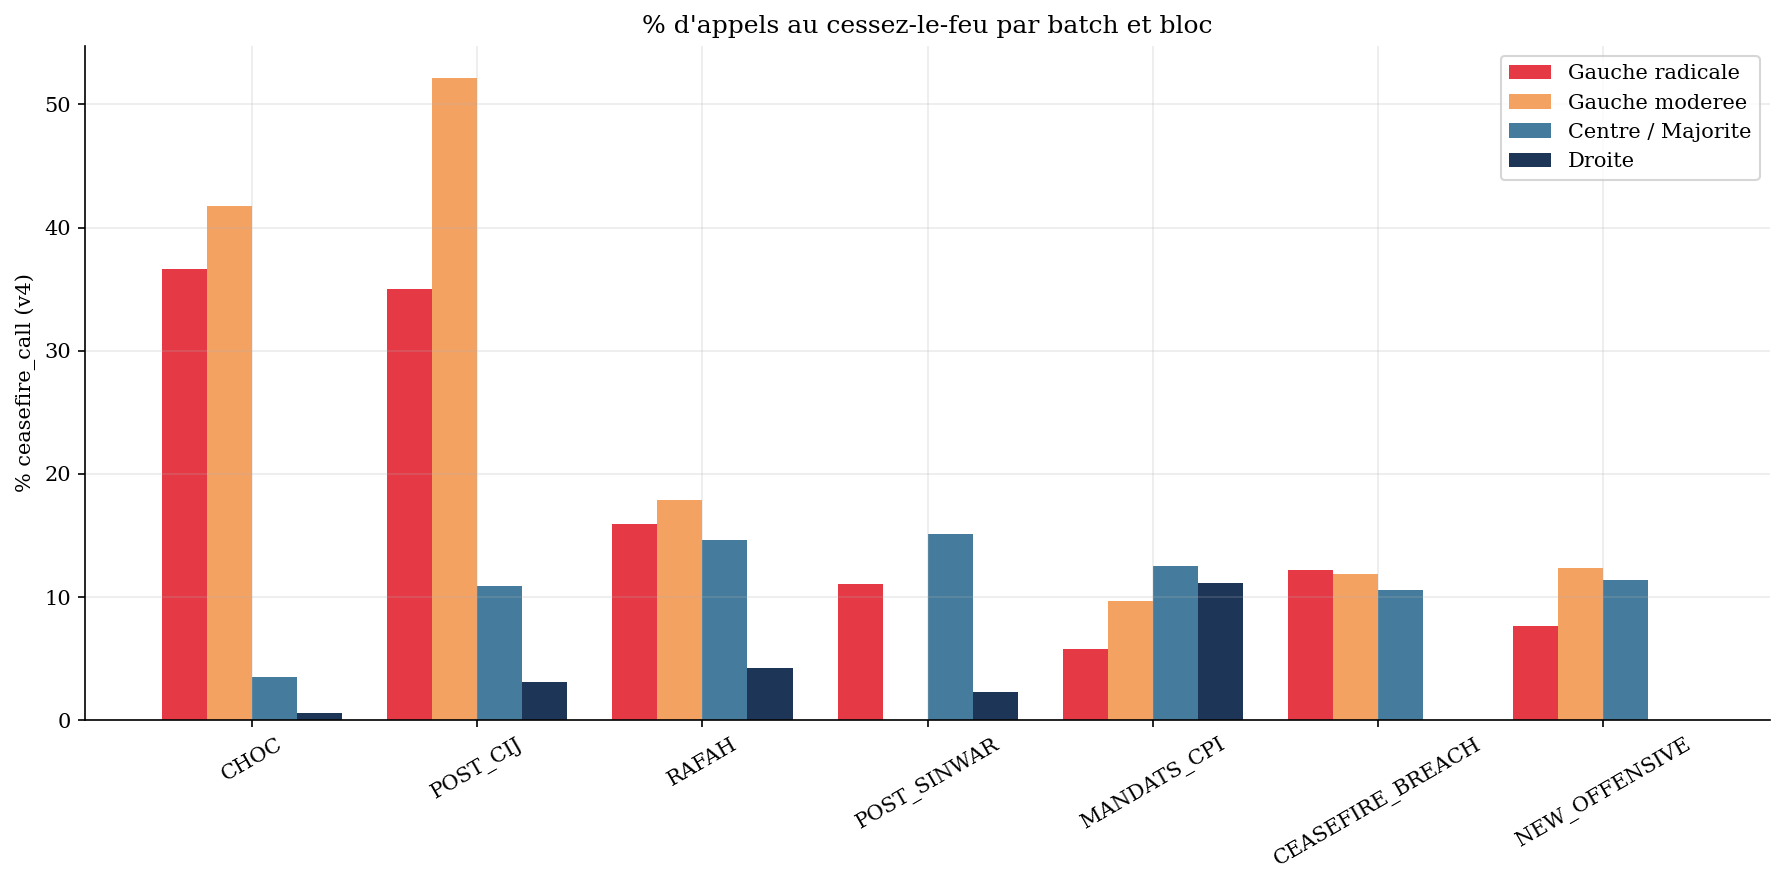

In [4]:
ceasefire_v4 = pd.read_csv(RESULTS_DIR / "ceasefire_call_v4.csv")
ceasefire_v4["batch_center"] = pd.to_datetime(ceasefire_v4["batch_center"])
batch_order = ceasefire_v4.drop_duplicates("batch").sort_values("batch_center")["batch"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(batch_order))
width = 0.2
for i, bloc in enumerate(BLOCS_ORDER):
    df = ceasefire_v4[ceasefire_v4["bloc"] == bloc].set_index("batch").reindex(batch_order)
    vals = df["pct_ceasefire_v4"].fillna(0).values
    ax.bar(x + i * width, vals, width, label=bloc, color=COLORS[bloc])
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(batch_order, rotation=30)
ax.set_ylabel("% ceasefire_call (v4)")
ax.set_title("% d'appels au cessez-le-feu par batch et bloc")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig06_ceasefire_by_batch.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation** : La Gauche radicale et modérée adoptent le lexique du cessez-le-feu dès le choc initial (oct. 2023). Le Centre/Majorité montre une montée progressive, notamment après Rafah (mai 2024). La Droite reste très faible sur ce registre.

## 2.3 Polarisation lexicale

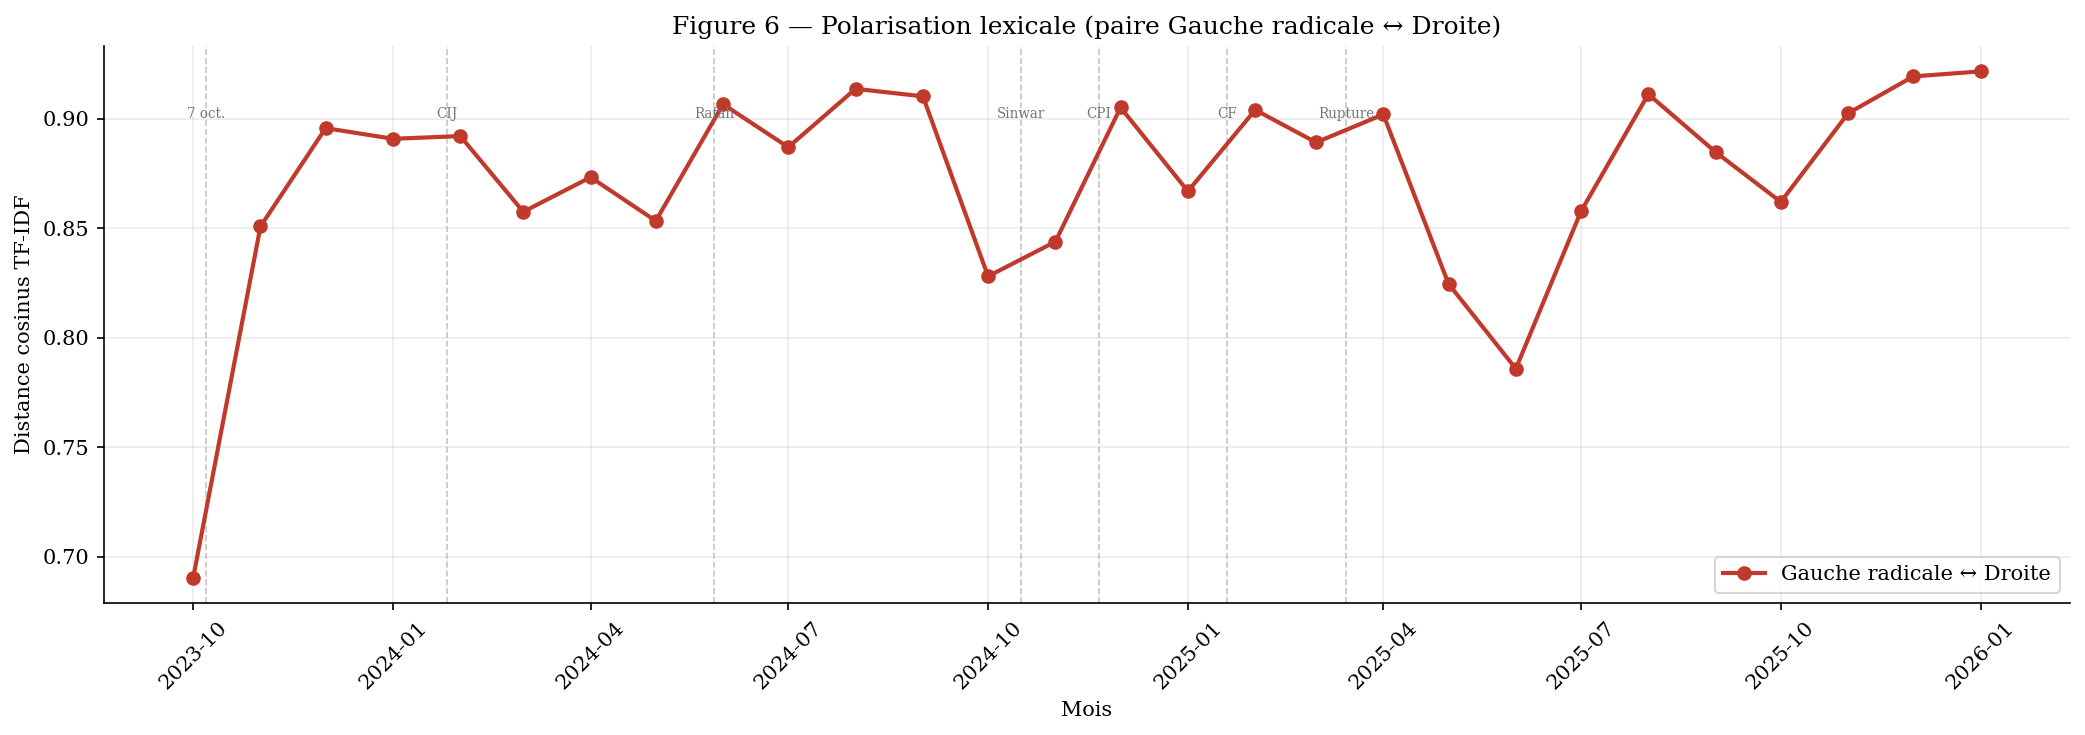

Figure 7 sauvegardée.


In [5]:
cos_dist = pd.read_csv(RESULTS_DIR / "cosine_distance_mensuelle.csv")
cos_dist["month"] = pd.to_datetime(cos_dist["month"] + "-01")

# Paire la plus polarisée : Gauche radicale ↔ Droite
pair_gr_dr = cos_dist[(cos_dist["bloc1"] == "Gauche radicale") & (cos_dist["bloc2"] == "Droite")]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pair_gr_dr["month"], pair_gr_dr["cosine_dist"], "o-", color="#c0392b", lw=2, label="Gauche radicale ↔ Droite")
add_events(ax)
ax.set_xlabel("Mois")
ax.set_ylabel("Distance cosinus TF-IDF")
ax.set_title("Figure 6. Polarisation lexicale (paire Gauche radicale ↔ Droite)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig07_polarisation_lexicale.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 7 sauvegardée.")

**Interprétation** : La distance cosinus entre Gauche radicale et Droite fluctue dans le temps. Une hausse indique une polarisation accrue (vocabulaire plus distinct) ; une baisse suggère une convergence lexicale.

## 2.4 Cadres discursifs (frames) par bloc

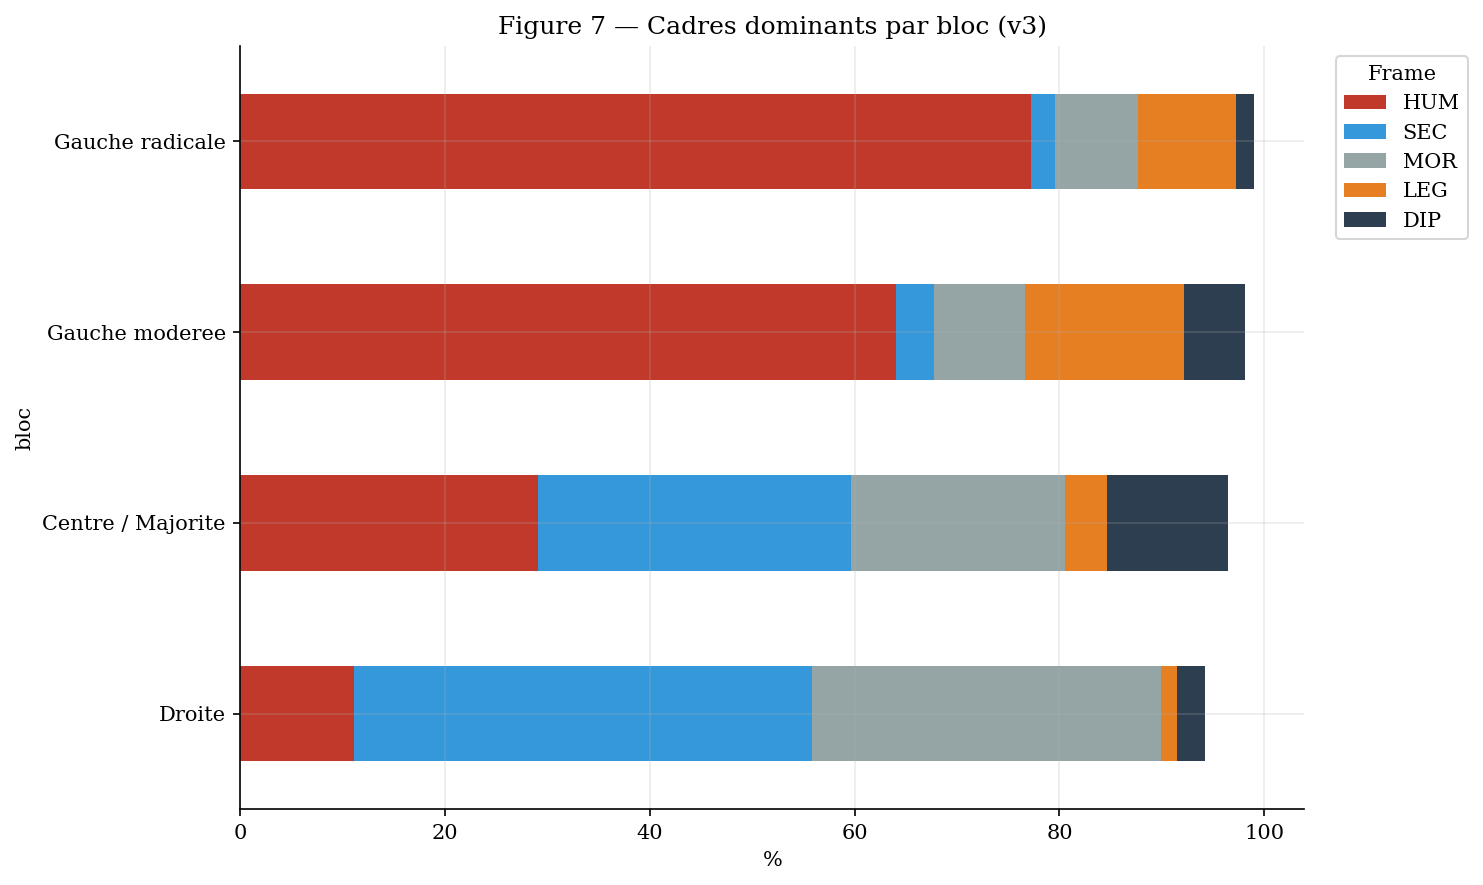

In [6]:
frames = pd.read_csv(RESULTS_DIR / "frames_par_bloc.csv")
frames_v3 = frames[frames["version"] == "v3"].copy()

fig, ax = plt.subplots(figsize=(10, 6))
pivot = frames_v3.pivot(index="bloc", columns="frame", values="pct").fillna(0)
pivot = pivot.reindex(BLOCS_ORDER)
top_frames = ["HUM", "SEC", "MOR", "LEG", "DIP"]
cols = [c for c in top_frames if c in pivot.columns]
pivot[cols].plot(kind="barh", stacked=True, ax=ax, color=["#c0392b", "#3498db", "#95a5a6", "#e67e22", "#2c3e50"][:len(cols)])
ax.set_xlabel("%")
ax.set_title("Figure 7. Cadres dominants par bloc (v3)")
ax.legend(title="Frame", bbox_to_anchor=(1.02, 1))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_frames_par_bloc.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation** : La Gauche privilégie le cadre humanitaire (HUM) ; la Droite et le Centre le cadre sécuritaire (SEC). Le cadre juridique (LEG) est plus présent à gauche et au centre.

## 2.5 Conditionnalité du cessez-le-feu

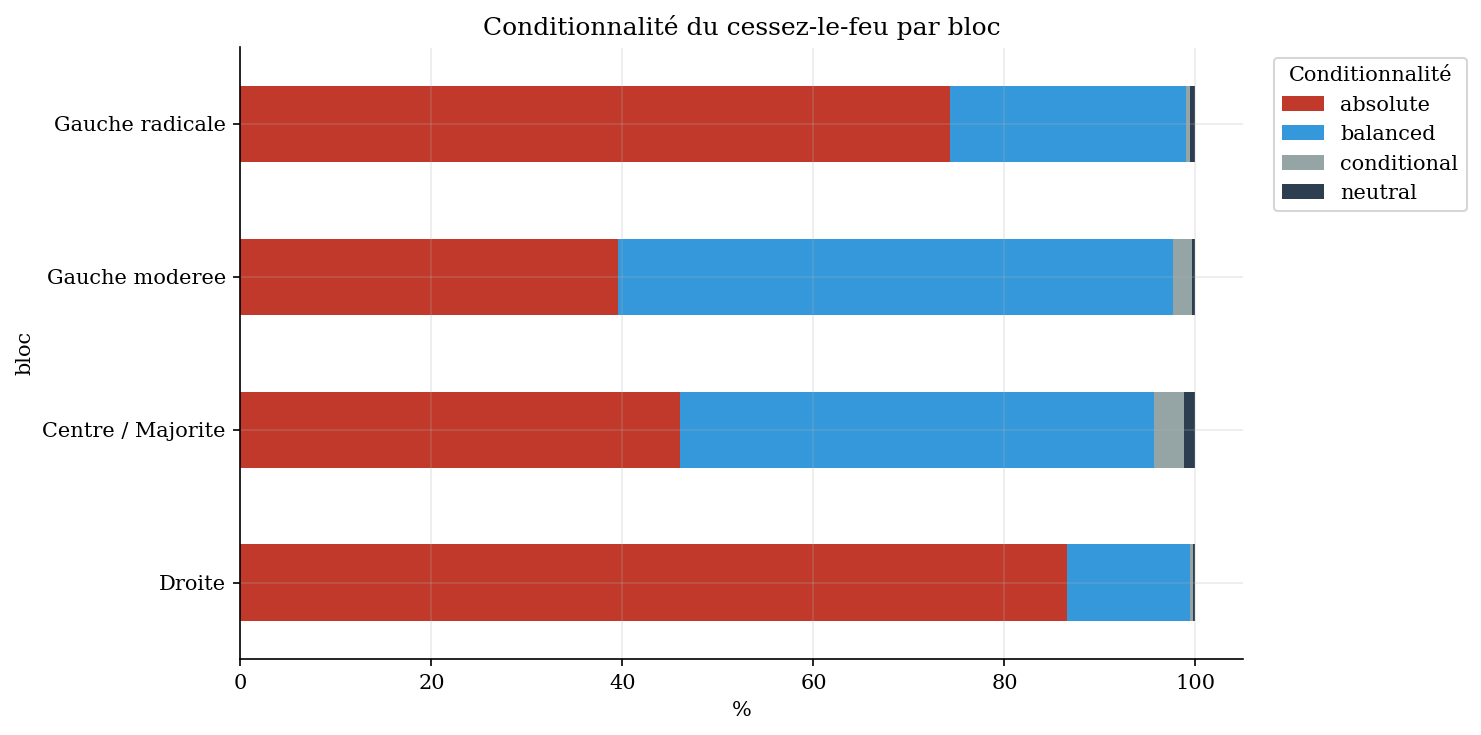

In [7]:
cond = pd.read_csv(RESULTS_DIR / "conditionality.csv")

fig, ax = plt.subplots(figsize=(10, 5))
pivot = cond.pivot(index="bloc", columns="conditionality", values="pct").fillna(0)
pivot = pivot.reindex(BLOCS_ORDER)
cond_order = ["absolute", "balanced", "conditional", "neutral"]
cols = [c for c in cond_order if c in pivot.columns]
pivot[cols].plot(kind="barh", stacked=True, ax=ax, color=["#c0392b", "#3498db", "#95a5a6", "#2c3e50"][:len(cols)])
ax.set_xlabel("%")
ax.set_title("Conditionnalité du cessez-le-feu par bloc")
ax.legend(title="Conditionnalité", bbox_to_anchor=(1.02, 1))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_conditionality.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.6 Registre émotionnel

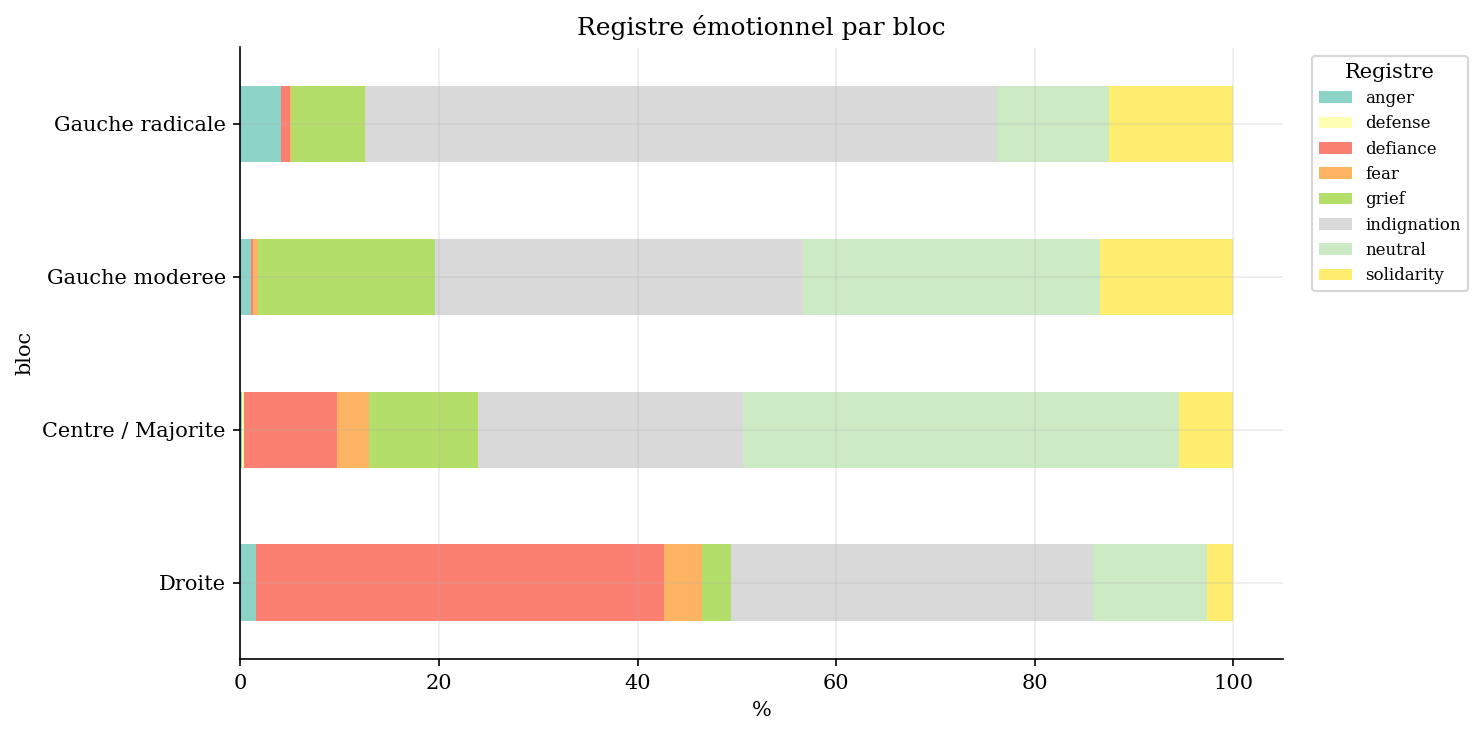

In [8]:
emotion = pd.read_csv(RESULTS_DIR / "emotional_register.csv")

fig, ax = plt.subplots(figsize=(10, 5))
pivot = emotion.pivot(index="bloc", columns="register", values="pct").fillna(0)
pivot = pivot.reindex(BLOCS_ORDER)
pivot.plot(kind="barh", stacked=True, ax=ax, colormap="Set3")
ax.set_xlabel("%")
ax.set_title("Registre émotionnel par bloc")
ax.legend(title="Registre", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_emotional_register.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation** : La Gauche radicale est dominée par l'indignation ; la Droite par la défiance. Le Centre montre plus de neutralité.

## 2.7 Event studies, impact des événements pivot

In [9]:
events = pd.read_csv(RESULTS_DIR / "event_impact_diff_in_diff.csv")
events_stance = events[events["variable"] == "stance_v3"].copy()

print("Changements de stance autour des événements (Mann-Whitney, * p<0.05, ** p<0.01):")
display(events_stance[["event", "bloc", "mean_avant", "mean_apres", "delta", "p_mannwhitney", "sig"]])

Changements de stance autour des événements (Mann-Whitney, * p<0.05, ** p<0.01):


,event,bloc,mean_avant,mean_apres,delta,p_mannwhitney,sig
0,Ordonnance CIJ,Gauche radicale,1.6429,1.5658,-0.0771,0.8709,NaN
1,Ordonnance CIJ,Gauche moderee,1.1176,1.2500,0.1324,0.4752,NaN
2,Ordonnance CIJ,Centre / Majorite,-0.6170,-1.0526,-0.4356,0.0179,*
3,Ordonnance CIJ,Droite,-1.5000,-1.2759,0.2241,0.3194,NaN
8,Offensive Rafah,Gauche radicale,1.6214,1.8261,0.2047,0.0009,**
9,Offensive Rafah,Gauche moderee,1.2353,1.3103,0.0751,0.7337,NaN
10,Offensive Rafah,Centre / Majorite,-0.8837,-0.4800,0.4037,0.0075,**
11,Offensive Rafah,Droite,-1.2500,-1.6744,-0.4244,0.1382,NaN
16,Mort Sinwar,Gauche radicale,1.6436,1.7686,0.1250,0.0646,NaN
17,Mort Sinwar,Gauche moderee,1.2000,1.5000,0.3000,0.6195,NaN


**Interprétation** : L'ordonnance CIJ (janv. 2024) produit un durcissement significatif du Centre. L'offensive Rafah (mai 2024) entraîne un renforcement du stance à gauche et une convergence du Centre vers des positions plus nuancées. Les mandats CPI n'ont pas d'effet significatif mesuré sur le stance.

## 2.8 Niveau individu : trajectoires, movers, variance

Les analyses par bloc masquent l'hétérogénéité intra-bloc. Cette section exploite les CSV étendus (`trajectoires_individuelles`, `variance_intra_bloc`, `movers_top20`) pour identifier les députés à forte variance de stance (movers) et comparer la dispersion entre blocs.

In [ ]:
var_bloc = pd.read_csv(RESULTS_DIR / "variance_intra_bloc.csv")
var_bloc = var_bloc.set_index("bloc").reindex(BLOCS_ORDER).dropna(how="all")
movers = pd.read_csv(RESULTS_DIR / "movers_top20.csv")
traj = pd.read_csv(RESULTS_DIR / "trajectoires_individuelles.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(var_bloc))
axes[0].bar(x, var_bloc["stance_std_global"], color=[COLORS[b] for b in var_bloc.index])
axes[0].set_xticks(x)
axes[0].set_xticklabels([b.replace(" ", "\n") for b in var_bloc.index], fontsize=9)
axes[0].set_ylabel("Écart-type intra-bloc")
axes[0].set_title("(a) Variance de stance par bloc")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)

axes[1].bar(x, var_bloc["pct_movers"] * 100, color=[COLORS[b] for b in var_bloc.index])
axes[1].set_xticks(x)
axes[1].set_xticklabels([b.replace(" ", "\n") for b in var_bloc.index], fontsize=9)
axes[1].set_ylabel("% movers (stance_range ≥ 3)")
axes[1].set_title("(b) Part de movers par bloc")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_variance_movers_bloc.png", dpi=150, bbox_inches="tight")
plt.show()

display(movers[["author", "bloc", "stance_mean", "stance_range", "n_textes"]].head(15))
print("\nMovers : députés dont le stance varie sur au moins 3 points (range ≥ 3). La Gauche radicale concentre le plus de movers.")

## Synthèse

- **Stance** : Polarisation stable ; Gauche pro-PAL, Droite pro-ISR.
- **Cessez-le-feu** : Diffusion progressive du Centre vers le Centre ; Droite quasi absente.
- **Polarisation lexicale** : Distance cosinus variable dans le temps.
- **Frames** : HUM dominant à gauche, SEC à droite.
- **Événements** : CIJ et Rafah produisent des shifts mesurables.

## Key Findings

- **Frames** : G.rad = monde HUM (77 %), Droite = monde SEC (45 %). Les blocs ne parlent pas du même conflit.
- **Registre émotionnel** : Droite defiance bondit à 51 % à POST_SINWAR ; G.rad indignation monte à 75 % à RAFAH.
- **Diffusion lexicale** : Le mot « cessez-le-feu » diffuse avec un décalage de 14 mois entre Gauche radicale et Droite.
- **Z-scores** : terrorisme z=-2.21 (Droite), colonisation z=+1.02 (Gauche). Fightin' words.
- **Conditionnalité** : G.rad 74 % absolute, Centre 50 % balanced / 46 % absolute, Droite 87 % absolute.

## Discussion littérature

La dominance du frame humanitaire à gauche et sécuritaire à droite est cohérente avec Kostikova et al. (2024) sur le Bundestag. Les z-scores (« terrorisme » z=-2.21, « colonisation » z=+1.02) illustrent les « fightin' words » de Monroe et al. (2008). La diffusion du cessez-le-feu avec un décalage de 14 mois entre Gauche radicale et Droite montre une perméabilité lexicale inter-blocs jamais documentée sur ce conflit dans le contexte français.